<a href="https://colab.research.google.com/github/encoras/Introduction-to-OpenCV/blob/master/amber_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tar -xzvf archyvas.tar.gz

In [84]:
import cv2
import numpy as np
from pathlib import Path
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm
from skimage import color

# === KONFIGŪRACIJA ===
DATA_ROOT = "/content/drive/MyDrive/Colab Notebooks/kevir_12_mazi"   # arba tavo kelias
CLASSES_TO_USE = ["NK01", "NK02","NK03","NK04","NK05","NK06","NK07","NK06","NK09","NK10","NK11", "NK12"]           # tik šviesiausia ir tamsiausia
PIXELS_PER_IMAGE = 8000                     # saugus skaičius (mažiau atminties)
N_CLUSTERS = 20

# === Surenkame pikselius tik iš dviejų klasių ===
print("Renkame LAB pikselius iš nk01 ir nk12...")

all_pixels = []

for class_name in CLASSES_TO_USE:
    class_dir = Path(DATA_ROOT) / class_name
    image_paths = list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpg"))

    print(f"→ {class_name}: {len(image_paths)} nuotraukų")

    for path in tqdm(image_paths[:20]):           # jei nori, gali apriboti
        img = cv2.imread(str(path))
        if img is None: continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        flat = img.reshape(-1, 3).astype(np.float32)

        # Imame atsitiktinius pikselius
        if len(flat) > PIXELS_PER_IMAGE:
            idx = np.random.choice(len(flat), PIXELS_PER_IMAGE, replace=False)
            flat = flat[idx]

        all_pixels.append(flat)

all_pixels = np.vstack(all_pixels)
print(f"Viso pikselių klasterizavimui: {len(all_pixels):,} ({all_pixels.nbytes / 1e9:.2f} GB)")

# === Klasterizavimas (greitas MiniBatchKMeans) ===
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=8192,
    random_state=42,
    n_init='auto'
)
kmeans.fit(all_pixels)

# Konvertuojame H iš 0-179 → 0-360
centers = kmeans.cluster_centers_.astype(int)


print("\nKlasterių centrai (H, S, V):")
for i, c in enumerate(centers):
    print(f"Klasteris {i:2d}:  H={c[0]:3d}  S={c[1]:3d}  V={c[2]:3d}")

Renkame LAB pikselius iš nk01 ir nk12...
→ NK01: 185 nuotraukų


  0%|          | 0/20 [00:00<?, ?it/s]

→ NK02: 190 nuotraukų


  0%|          | 0/20 [00:00<?, ?it/s]

→ NK03: 199 nuotraukų


...

→ NK11: 195 nuotraukų


  0%|          | 0/20 [00:00<?, ?it/s]

→ NK12: 198 nuotraukų


  0%|          | 0/20 [00:00<?, ?it/s]

Viso pikselių klasterizavimui: 1,920,000 (0.02 GB)

Klasterių centrai (H, S, V):
Klasteris  0:  H= 92  S= 50  V=162
Klasteris  1:  H= 14  S=191  V= 65
Klasteris  2:  H= 38  S= 52  V=104
Klasteris  3:  H= 24  S=158  V=169
Klasteris  4:  H= 92  S= 51  V=177
Klasteris  5:  H= 86  S= 45  V=142
Klasteris  6:  H= 89  S= 42  V=166
Klasteris  7:  H= 21  S=137  V= 72
Klasteris  8:  H= 90  S= 44  V=157
Klasteris  9:  H= 17  S=190  V=113
Klasteris 10:  H= 93  S= 57  V=168
Klasteris 11:  H= 29  S= 56  V= 31
Klasteris 12:  H= 87  S= 36  V=157
Klasteris 13:  H= 34  S= 90  V=225
Klasteris 14:  H= 92  S= 49  V=169
Klasteris 15:  H= 93  S= 54  V=155
Klasteris 16:  H= 85  S= 34  V=109
Klasteris 17:  H= 15  S=222  V= 33
Klasteris 18:  H= 94  S= 59  V=179
Klasteris 19:  H= 90  S= 43  V=175


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys
from skimage import color
# Tarkime, kad jau turi:
centers_hsv = kmeans.cluster_centers_   # shape (n_clusters, 3) → L*, a*, b*
labels      = kmeans.labels_

# ────────────────────────────────────────────────────────────────
# 1. LAB → RGB konversija (0–1 diapazonas matplotlib'ui)
# ────────────────────────────────────────────────────────────────



cluster_rgb = (color.hsv2rgb(centers_hsv/255))  # naudok aukščiau pateiktą funkciją

cluster_sizes  = np.bincount(labels, minlength=len(centers_hsv))
total_pixels   = len(labels)
cluster_percent = (cluster_sizes / total_pixels) * 100

# Vizualizacija
fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(1, 2, 1)
ax1.pie(
    cluster_percent,
    labels=[f'Cl {i}\n{perc:.1f}%' for i, perc in enumerate(cluster_percent)],
    autopct='%1.1f%%',
    colors=cluster_rgb,
    startangle=90,
    pctdistance=0.75
)
ax1.set_title("Klasterių pasiskirstymas (%)")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow([[rgb] for rgb in cluster_rgb], aspect='auto')

ax2.set_yticks(range(len(cluster_rgb)))
ax2.set_yticklabels([
    f"Cl {i:2d}  {perc:5.1f}%   RGB({int(r*255):3d},{int(g*255):3d},{int(b*255):3d})\n"
    f"H={(L):5.0f} S={(a):5.0f} V={(v):5.0f}"
    for i, (L,a,v), (r,g,b), perc in zip(range(len(centers_hsv)), centers_hsv, cluster_rgb, cluster_percent)
], fontsize=9)

ax2.set_xticks([])
ax2.set_title("Klasterių spalvos (RGB)")

plt.tight_layout()
plt.show()

In [ ]:
# ========================== 1. INSTALIACIJA IR IMPORTAI ==========================
!pip install opencv-python-headless scikit-learn pandas matplotlib seaborn -q

import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab.patches import cv2_imshow

# ========================== 2. KONFIGŪRACIJA ==========================
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/kevir_12_mazi"   # ← pakeisk į savo kelią

# HSV ribos gintarui (labai gerai veikia ant šviesaus fono)
#LOWER_AMBER = np.array([ 6,  20,  25])   # H, S, V
#UPPER_AMBER = np.array([ 40, 205, 180])

#LOWER_AMBER = np.array([ 10,  70,  30 ])   # H min ≈12-2, S min ≈73-3, V min ≈37-7
#UPPER_AMBER = np.array([ 45, 255, 255 ])   # H max ≈37+8, S max, V max
LOWER_AMBER = np.array([  0,  30,  15 ])
UPPER_AMBER = np.array([ 50, 255, 255 ])

# Morfologija
KERNEL = np.ones((5,5), np.uint8)

def segment_dark_amber(hsv):
    # Tamsiems gintarams – platesnis H, mažesnis V minimumas
    lower_dark = np.array([ 0,  30,  15 ])
    upper_dark = np.array([ 45, 255, 180 ])  # V iki 180, kad neperimtų šviesaus fono
    return cv2.inRange(hsv, lower_dark, upper_dark)

def segment_light_amber(hsv):
    lower_light = np.array([ 15,  80,  80 ])
    upper_light = np.array([ 40, 255, 255 ])
    return cv2.inRange(hsv, lower_light, upper_light)



# ========================== 3. SEGMENTAVIMO FUNKCIJA ==========================
def segment_amber(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    #mask = cv2.inRange(hsv, LOWER_AMBER, UPPER_AMBER)
    # Sujungimas
    mask_dark  = segment_dark_amber(hsv)
    mask_light = segment_light_amber(hsv)
    mask = cv2.bitwise_or(mask_dark, mask_light)


    # Valymas
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, KERNEL)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, KERNEL)

    # Imame didžiausią kontūrą (kad nebūtų triukšmo)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None

    largest = max(contours, key=cv2.contourArea)
    mask_clean = np.zeros(mask.shape, np.uint8)
    cv2.drawContours(mask_clean, [largest], -1, 255, -1)

    return img, mask_clean

# ========================== 4. FEATURE EXTRACTION (LAB) ==========================
def extract_features(img, mask):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    masked_lab = lab[mask > 0]

    if len(masked_lab) < 100:  # per mažas gabalėlis
        return None

    mean_l, mean_a, mean_b = np.mean(masked_lab, axis=0)
    std_l,  std_a,  std_b  = np.std(masked_lab, axis=0)

    # Papildomi požymiai
    area = np.sum(mask > 0)
    perimeter = cv2.arcLength(cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0][0], True)
    circularity = 4 * np.pi * area / (perimeter * perimeter + 1e-6)

    return {
        'mean_L': mean_l, 'mean_A': mean_a, 'mean_B': mean_b,
        'std_L':  std_l,  'std_A':  std_a,  'std_B':  std_b,
        'area': area, 'circularity': circularity
    }

# ========================== 5. DUOMENŲ SURINKIMAS (TRAINING) ==========================
features_list = []
labels = []

print("✅ Renkame duomenis iš nk01-nk12...")

for nk_folder in sorted(Path(DATASET_PATH).glob("NK*")):
    class_name = nk_folder.name
    for img_path in nk_folder.glob("*.*"):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue

        img, mask = segment_amber(img_path)
        if img is None or mask is None:
            continue

        feat = extract_features(img, mask)
        if feat:
            features_list.append(feat)
            labels.append(class_name)

        # Parodome pirmus 3 pavyzdžius iš kiekvienos klasės
        if len(features_list) % 50 == 0:
            cv2_imshow(cv2.bitwise_and(img, img, mask=mask))

df = pd.DataFrame(features_list)
df['label'] = labels
print(f"✅ Surinkta {len(df)} pavyzdžių iš {len(df['label'].unique())} klasių")
df.head()

In [87]:
df.describe()

,mean_L,mean_A,mean_B,std_L,std_A,std_B,area,circularity
count,2304.00,2304.00,2304.00,2304.00,2304.00,2304.00,2304.00,2304.00
mean,19.37,166.92,80.66,8.56,38.17,24.21,12698.54,0.70
std,7.59,31.95,39.16,4.25,10.42,14.02,4138.65,0.14
min,6.81,49.86,16.31,2.72,9.55,2.04,108.00,0.08
25%,13.80,155.52,49.94,4.85,32.74,12.28,11206.00,0.73
50%,16.81,177.36,77.24,8.12,36.93,21.14,13265.00,0.75
75%,22.72,188.34,107.14,11.06,42.17,33.61,15153.50,0.76
max,51.43,217.05,193.83,33.05,83.09,69.05,27046.00,0.92


🎯 Tikslumas: 0.8680555555555556
              precision    recall  f1-score   support

        NK01       0.98      1.00      0.99        46
        NK02       0.93      0.89      0.91        47
        NK03       0.86      0.86      0.86        50
        NK04       0.79      0.78      0.78        49
        NK05       0.73      0.76      0.75        50
        NK06       0.74      0.69      0.72        49
        NK07       0.81      0.80      0.80        49
        NK08       0.92      0.94      0.93        49
        NK09       0.96      0.96      0.96        49
        NK10       0.87      0.92      0.89        49
        NK11       0.92      0.90      0.91        49
        NK12       0.93      0.95      0.94        40

    accuracy                           0.87       576
   macro avg       0.87      0.87      0.87       576
weighted avg       0.87      0.87      0.87       576



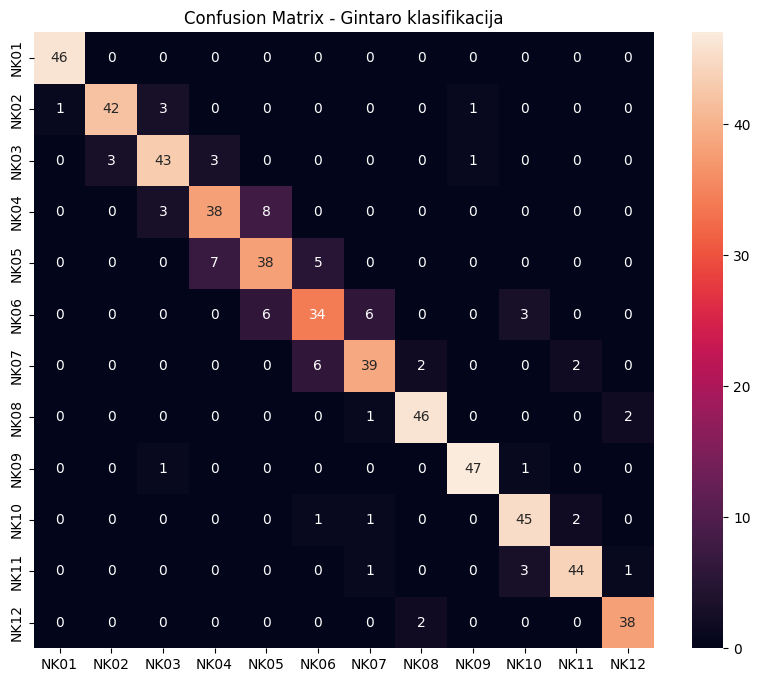

In [88]:
# ========================== MOKYMAS ==========================
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=200, max_depth=9,
                             random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# ========================== REZULTATAI ==========================
y_pred = clf.predict(X_test)
print("🎯 Tikslumas:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title("Confusion Matrix - Gintaro klasifikacija")
plt.show()

In [89]:
!pip install lazypredict

In [90]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)   # ← graži lentelė su ~30 modelių rezultatais

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1728, number of used features: 8
[LightGBM] [Info] Start training from score -2.520246
[LightGBM] [Info] Start training from score -2.491875
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.464287
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.457508
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.464287
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.675596
[

In [91]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler



scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

clf = LazyClassifier(verbose=0, ignore_warnings=True)
models, _ = clf.fit(X_train_sc, X_test_sc, y_train, y_test)
print(models[['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score']].head(5))

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1728, number of used features: 8
[LightGBM] [Info] Start training from score -2.520246
[LightGBM] [Info] Start training from score -2.491875
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.464287
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.457508
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.464287
[LightGBM] [Info] Start training from score -2.450774
[LightGBM] [Info] Start training from score -2.471113
[LightGBM] [Info] Start training from score -2.675596
[LightGBM] [Warning] No further splits with positive gain, best g